In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Works when launched from the repository root or this notebook's directory.
PROJECT_ROOT = next(
    (parent for parent in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
     if (parent / "benchmark/examples/diffusion/config.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from inside the benchmark2 repository.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import BASE_DIR, MODELS
from benchmark.examples.diffusion.analysis.direct_diagnostics import ensure_direct_diagnostics
from benchmark.examples.diffusion.analysis.direct_calibration import ensure_direct_pmp_thresholds

RESULTS_DIR = BASE_DIR / "results" / "direct"
INDIRECT_TAG = "S4D"  # Existing with-MMD baseline used by direct_cent.ipynb.
EXPECTED_LOSSES = ("cross_entropy", "exponential", "logistic")
LOSS_FUNCTIONS = tuple(
    loss for loss in EXPECTED_LOSSES
    if (BASE_DIR / "networks" / f"direct_{loss}.keras").is_file()
)
MISSING_LOSSES = tuple(loss for loss in EXPECTED_LOSSES if loss not in LOSS_FUNCTIONS)
LOSS_LABELS = {
    "cross_entropy": "Cross-entropy",
    "exponential": "Exponential",
    "logistic": "Logistic",
}
print("Available direct checkpoints:", ", ".join(LOSS_FUNCTIONS) or "none")
print("Missing direct checkpoints:", ", ".join(MISSING_LOSSES) or "none")
if MISSING_LOSSES:
    print("Missing losses are excluded; this notebook does not train or substitute checkpoints.")
if not LOSS_FUNCTIONS:
    raise FileNotFoundError(f"No direct checkpoints found in {BASE_DIR / 'networks'}")

FIGURE_DIR = RESULTS_DIR / "direct_loss_comparison" / "figures"
DATASETS_TO_PLOT = None  # None: all available sources; e.g. ("empirical", "m3_fast_30")
FIGURE_SUFFIX = "all"  # Change together with DATASETS_TO_PLOT for a saved subset.

# Validate/recompute both direct diagnostics and PMP before reading their CSVs.
# Each loss uses its own trained summary network; compatible caches are reused.
diagnostic_frames_by_loss = {
    loss: ensure_direct_diagnostics(loss, results_dir=RESULTS_DIR, indirect_tag=INDIRECT_TAG)
    for loss in LOSS_FUNCTIONS
}
# Reuse the same 100-per-model calibration reference as the indirect benchmark.
threshold_frames_by_loss = {
    loss: ensure_direct_pmp_thresholds(loss, results_dir=RESULTS_DIR)
    for loss in LOSS_FUNCTIONS
}


Available direct checkpoints: cross_entropy
Missing direct checkpoints: exponential, logistic
Missing losses are excluded; this notebook does not train or substitute checkpoints.


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
comparison_by_loss = {}
indirect_configurations = set()
probability_columns = [
    f"p_{method}_{model}"
    for method in ("gold", "indirect", "direct") for model in MODELS
]
for loss in LOSS_FUNCTIONS:
    path = RESULTS_DIR / f"direct_{loss}" / "pmp_comparison.csv"
    frame = pd.read_csv(path, dtype={"dataset": str, "id": str})
    if frame[["dataset", "id"]].isna().any().any():
        raise ValueError(f"Missing dataset keys in {path}")
    frame = frame.set_index(["dataset", "id"]).sort_index()
    if not frame.index.is_unique:
        raise ValueError(f"Duplicate dataset keys in {path}")
    probabilities = frame[probability_columns].to_numpy(dtype=float)
    if not np.isfinite(probabilities).all() or not (
        (probabilities >= -1e-7) & (probabilities <= 1 + 1e-7)
    ).all():
        raise ValueError(f"Invalid or missing PMP values in {path}")
    if "indirect_configuration" not in frame or frame["indirect_configuration"].isna().any():
        raise ValueError(f"Missing indirect configuration provenance in {path}")
    indirect_configurations.update(frame["indirect_configuration"].unique())
    comparison_by_loss[loss] = frame

if len(indirect_configurations) != 1:
    raise ValueError(f"Expected one shared indirect baseline: {indirect_configurations}")
INDIRECT_LABEL = next(iter(indirect_configurations))
reference_frame = comparison_by_loss[LOSS_FUNCTIONS[0]]
reference_index = reference_frame.index
if reference_index.empty:
    raise ValueError("The PMP comparison files contain no datasets.")
shared_columns = [f"p_{method}_{model}" for method in ("gold", "indirect") for model in MODELS]
for loss, frame in comparison_by_loss.items():
    if not frame.index.equals(reference_index):
        missing = reference_index.difference(frame.index)
        extra = frame.index.difference(reference_index)
        raise ValueError(f"Dataset mismatch for {loss}: {len(missing)} missing, {len(extra)} extra.")
    if not np.allclose(frame[shared_columns], reference_frame[shared_columns], rtol=0, atol=1e-12):
        raise ValueError(f"Gold or indirect PMP differs across losses for {loss}")

available_datasets = tuple(reference_index.get_level_values("dataset").unique())
selected_datasets = available_datasets if DATASETS_TO_PLOT is None else tuple(DATASETS_TO_PLOT)
if not selected_datasets or len(set(selected_datasets)) != len(selected_datasets):
    raise ValueError("DATASETS_TO_PLOT must contain distinct observed source names.")
missing_datasets = set(selected_datasets) - set(available_datasets)
if missing_datasets:
    raise ValueError(f"Observed sources missing from the comparison files: {sorted(missing_datasets)}")
selected_index = reference_index[
    reference_index.get_level_values("dataset").isin(selected_datasets)
]
plot_data_by_loss = {
    loss: comparison_by_loss[loss].loc[selected_index].copy()
    for loss in LOSS_FUNCTIONS
}
figure_suffix = FIGURE_SUFFIX
for loss in LOSS_FUNCTIONS:
    print(f"Loaded {len(comparison_by_loss[loss])} datasets for {loss}.")
print(f"Indirect baseline: {INDIRECT_LABEL}")
print(f"Plotting {len(selected_index)} datasets per loss from: {', '.join(selected_datasets)}")
pd.concat(plot_data_by_loss, names=["loss_function"]).head()


Loaded 136 datasets for cross_entropy.
Indirect baseline: S4D
Plotting 136 datasets per loss from: empirical, m3_fast_30, m3_fast_slow_30, m3_slow_30, simulated_from_m0, simulated_from_m1, simulated_from_m2, simulated_from_m3


p_gold_m0  p_gold_m1  ...  l1_indirect  l1_direct
loss_function dataset   id                            ...                        
cross_entropy empirical p0   8.412650e-08   0.976227  ...     0.091809   0.005959
                        p1   6.436365e-30   0.344260  ...     0.456635   1.166971
                        p10  2.445768e-22   0.914936  ...     0.057922   0.003865
                        p11  4.662282e-20   0.248481  ...     0.137956   1.153079
                        p12  2.386724e-13   0.890941  ...     0.024188   0.090539

[5 rows x 15 columns]

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/pmp_recovery_all_losses_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/pmp_recovery_all_losses_all.pdf


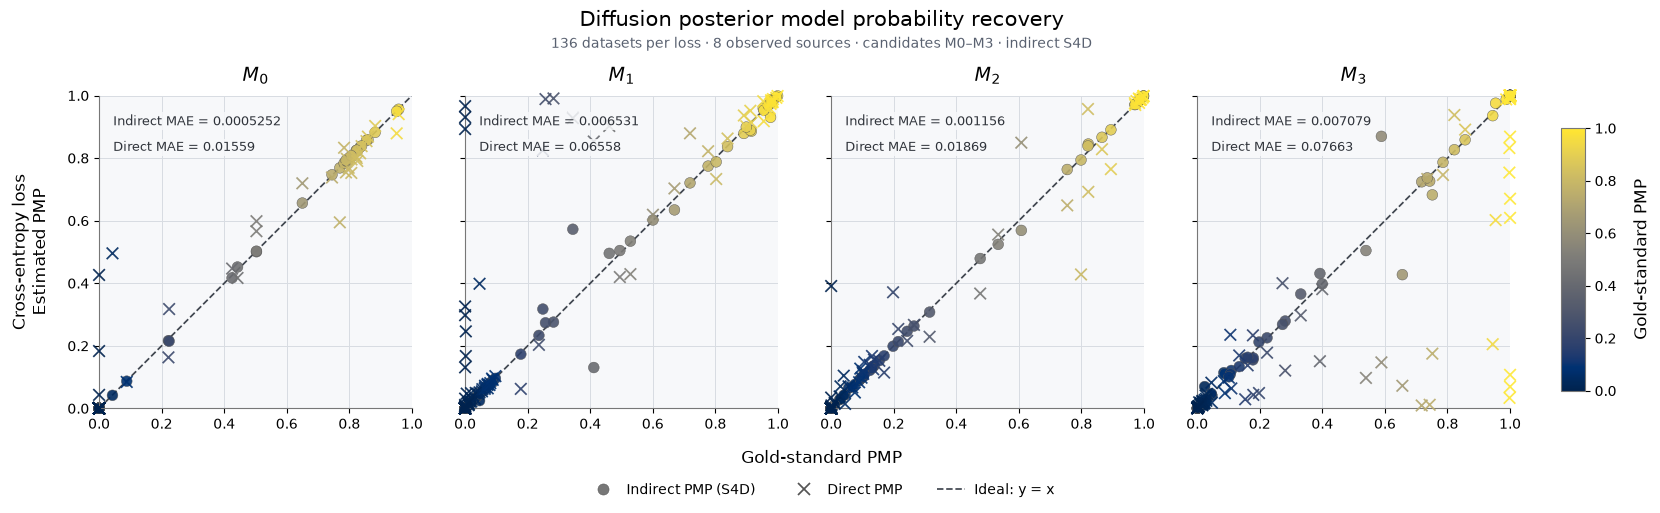

In [3]:
with plt.rc_context({
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#777777",
    "grid.color": "#D8DCE2",
    "grid.linewidth": 0.7,
    "savefig.facecolor": "white",
}):
    pmp_norm = Normalize(vmin=0.0, vmax=1.0)
    pmp_cmap = plt.get_cmap("cividis")
    figure_height = 4.0 * len(LOSS_FUNCTIONS) + 1.25
    fig, axes = plt.subplots(
        len(LOSS_FUNCTIONS), len(MODELS), figsize=(17, figure_height),
        sharex=True, sharey=True, squeeze=False,
    )
    fig.subplots_adjust(
        left=0.075, right=0.905, bottom=0.95 / figure_height, top=1 - 0.80 / figure_height,
        wspace=0.17, hspace=0.20,
    )

    for loss, row_axes in zip(LOSS_FUNCTIONS, axes):
        plot_data = plot_data_by_loss[loss]

        for model, ax in zip(MODELS, row_axes):
            gold = plot_data[f"p_gold_{model}"].to_numpy(dtype=float)
            indirect = plot_data[f"p_indirect_{model}"].to_numpy(dtype=float)
            direct = plot_data[f"p_direct_{model}"].to_numpy(dtype=float)

            ax.set_facecolor("#F7F8FA")
            ax.set_axisbelow(True)
            ax.grid(True)
            ax.plot([0, 1], [0, 1], "--", color="#40464F", lw=1.25, zorder=1)
            ax.scatter(
                gold, indirect, s=60, marker="o", c=gold, cmap=pmp_cmap, norm=pmp_norm,
                alpha=0.90, edgecolors="#555555", linewidths=0.35,
                zorder=2, clip_on=False,
            )
            ax.scatter(
                gold, direct, s=70, marker="x", c=gold, cmap=pmp_cmap, norm=pmp_norm,
                alpha=0.90, linewidths=1.25, zorder=3, clip_on=False,
            )
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_aspect("equal", adjustable="box")

            for y, method, estimate in (
                (0.94, "indirect", indirect),
                (0.855, "direct", direct),
            ):
                mae = np.mean(np.abs(estimate - gold))
                ax.text(
                    0.045, y, f"{method.capitalize()} MAE = {mae:.4g}",
                    transform=ax.transAxes, color="#30343B",
                    ha="left", va="top", fontsize=9.1,
                    bbox={"facecolor": "#F7F8FA", "edgecolor": "none", "alpha": 0.85, "pad": 1.5},
                    zorder=4,
                )

        row_axes[0].set_ylabel(
            f"{LOSS_LABELS[loss]} loss\nEstimated PMP", labelpad=12,
        )

    for model, ax in zip(MODELS, axes[0]):
        ax.set_title(rf"$M_{model[1:]}$", pad=10)

    fig.supxlabel("Gold-standard PMP", y=0.55 / figure_height, fontsize=12)
    fig.suptitle("Diffusion posterior model probability recovery", y=1 - 0.13 / figure_height, fontsize=15)
    fig.text(
        0.5, 1 - 0.47 / figure_height,
        f"{len(selected_index)} datasets per loss · {len(selected_datasets)} observed sources · "
        f"candidates M0–M3 · indirect {INDIRECT_LABEL}",
        ha="center", va="center", color="#596170", fontsize=10,
    )
    legend_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=8,
               markerfacecolor="#777777", markeredgecolor="#555555", markeredgewidth=0.35,
               label=f"Indirect PMP ({INDIRECT_LABEL})"),
        Line2D([], [], linestyle="none", marker="x", markersize=8,
               color="#555555", markeredgewidth=1.25, label="Direct PMP"),
        Line2D([], [], linestyle="--", color="#40464F", lw=1.25, label="Ideal: y = x"),
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.12 / figure_height),
        ncol=3, frameon=False, columnspacing=2.5, handletextpad=0.7,
    )

    # The same gold-standard PMP determines both methods' color in every panel.
    colorbar_ax = fig.add_axes([0.935, 0.25, 0.014, 0.50])
    colorbar = fig.colorbar(
        ScalarMappable(norm=pmp_norm, cmap=pmp_cmap), cax=colorbar_ax,
        ticks=np.linspace(0.0, 1.0, 6),
    )
    colorbar.set_label("Gold-standard PMP", labelpad=12)
    colorbar.outline.set_edgecolor("#777777")

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    png_path = FIGURE_DIR / f"pmp_recovery_all_losses_{figure_suffix}.png"
    pdf_path = FIGURE_DIR / f"pmp_recovery_all_losses_{figure_suffix}.pdf"
    fig.savefig(png_path, dpi=250, bbox_inches="tight", pad_inches=0.12)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.12)
    plt.show()

print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")


In [4]:
DIAGNOSTICS = ("l2", "linf", "density", "mmd")
DIAGNOSTIC_TITLES = (r"$L_2$", r"$L_\infty$", "Density", "Kernel")
DIAGNOSTIC_XLABELS = (
    r"Diagnostic: $L_2$-based", r"Diagnostic: $L_\infty$-based",
    "Diagnostic: density-based", "Diagnostic: Kernel-based",
)
LOSS_COLORS = {"cross_entropy": "#0072B2", "exponential": "#E69F00", "logistic": "#CC79A7"}
CLASS_STYLES = {
    False: ("o", 40, "all high surprise"),
    True: ("D", 60, "at least one not high surprise"),
}

diagnostic_data_by_loss = {}
for loss in LOSS_FUNCTIONS:
    diagnostics = diagnostic_frames_by_loss[loss].copy()
    keys = ["diagnostic", "assumed_model", "dataset", "id"]
    if diagnostics[keys].isna().any().any():
        raise ValueError(f"Missing diagnostic keys for {loss}")
    diagnostics["id"] = diagnostics["id"].astype(str)
    diagnostics = diagnostics.set_index(keys).sort_index()
    if not diagnostics.index.is_unique:
        raise ValueError(f"Duplicate diagnostic keys for {loss}")

    expected_index = pd.MultiIndex.from_tuples(
        [(diagnostic, model, dataset_name, dataset_id)
         for diagnostic in DIAGNOSTICS for model in MODELS
         for dataset_name, dataset_id in reference_index],
        names=keys,
    ).sort_values()
    if not diagnostics.index.equals(expected_index):
        missing = expected_index.difference(diagnostics.index)
        extra = diagnostics.index.difference(expected_index)
        raise ValueError(
            f"Diagnostic/PMP dataset mismatch for {loss}: "
            f"{len(missing)} missing, {len(extra)} extra diagnostic rows."
        )
    if not np.isfinite(diagnostics[["rho", "rho_low"]].to_numpy(dtype=float)).all():
        raise ValueError(f"Non-finite diagnostic values for {loss}")
    flags = diagnostics["at_least_one_not_extrapolative"]
    if flags.isna().any() or not flags.isin([True, False]).all():
        raise ValueError(f"Invalid surprise classifications for {loss}")

    for diagnostic in DIAGNOSTICS:
        for model in MODELS:
            lows = diagnostics.loc[(diagnostic, model), "rho_low"].unique()
            if len(lows) != 1 or lows[0] > 1:
                raise ValueError(f"Invalid reference interval for {loss}/{diagnostic}/{model}")
    diagnostic_data_by_loss[loss] = diagnostics
    print(f"Validated {len(diagnostics)} direct diagnostic rows for {loss}.")

# Match the existing benchmark: row M_j uses calibration source M_j,
# with all four signed PMP component errors pooled before taking quantiles.
pmp_thresholds_by_loss = {}
for loss in LOSS_FUNCTIONS:
    thresholds = threshold_frames_by_loss[loss]
    thresholds = thresholds.loc[thresholds["metric"].eq("signed_pmp_error")].copy()
    if not thresholds["loss_function"].eq(loss).all():
        raise ValueError(f"Mismatched loss in direct PMP thresholds for {loss}")
    thresholds = thresholds.set_index("generating_model").sort_index()
    if not thresholds.index.is_unique or set(thresholds.index) != set(MODELS):
        raise ValueError(f"Expected one direct PMP threshold row per generating model for {loss}")
    bounds = thresholds[["lower_threshold", "median", "threshold"]].to_numpy(dtype=float)
    if not np.isfinite(bounds).all() or not (np.diff(bounds, axis=1) >= 0).all():
        raise ValueError(f"Invalid direct PMP calibration interval for {loss}")
    counts = pd.to_numeric(thresholds["n_values"], errors="raise")
    if not ((counts > 0) & (counts <= 100 * len(MODELS)) & (counts % len(MODELS) == 0)).all():
        raise ValueError(f"Invalid convergence-filtered PMP calibration counts for {loss}")
    pmp_thresholds_by_loss[loss] = thresholds
    retained = {model: int(counts.loc[model] // len(MODELS)) for model in MODELS}
    print(f"Validated direct PMP calibration intervals for {loss}; retained datasets: {retained}")


TYPICAL_SET_FILL = "#DCEEDC"


def add_direct_background_regions(ax, panels, threshold_rows):
    """Match the background aggregation in the Gaussian direct comparison background rule."""
    rho_lows = [float(panel["rho_low"].median()) for panel in panels.values()]
    # All upper reference bounds normalize to 1: this is the interval union.
    ax.axvspan(min(rho_lows), 1.0, color=TYPICAL_SET_FILL, alpha=0.70, zorder=0)
    ax.axvline(1.0, color="0.25", linestyle="--", linewidth=0.9, zorder=1)

    bounds = [
        (float(row["lower_threshold"]), float(row["threshold"]))
        for row in threshold_rows.values()
    ]
    band_low = max(low for low, high in bounds)
    band_high = min(high for low, high in bounds)
    if band_low <= band_high:
        ax.axhspan(band_low, band_high, color=TYPICAL_SET_FILL, alpha=0.70, zorder=0)
    else:
        ax.axhspan(
            min(low for low, high in bounds), max(high for low, high in bounds),
            color=TYPICAL_SET_FILL, alpha=0.25, zorder=0,
        )


Validated 2176 direct diagnostic rows for cross_entropy.
Validated direct PMP calibration intervals for cross_entropy; retained datasets: {'m0': 100, 'm1': 100, 'm2': 100, 'm3': 100}


/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/direct_pmp_error_all_losses_by_diagnostic_all


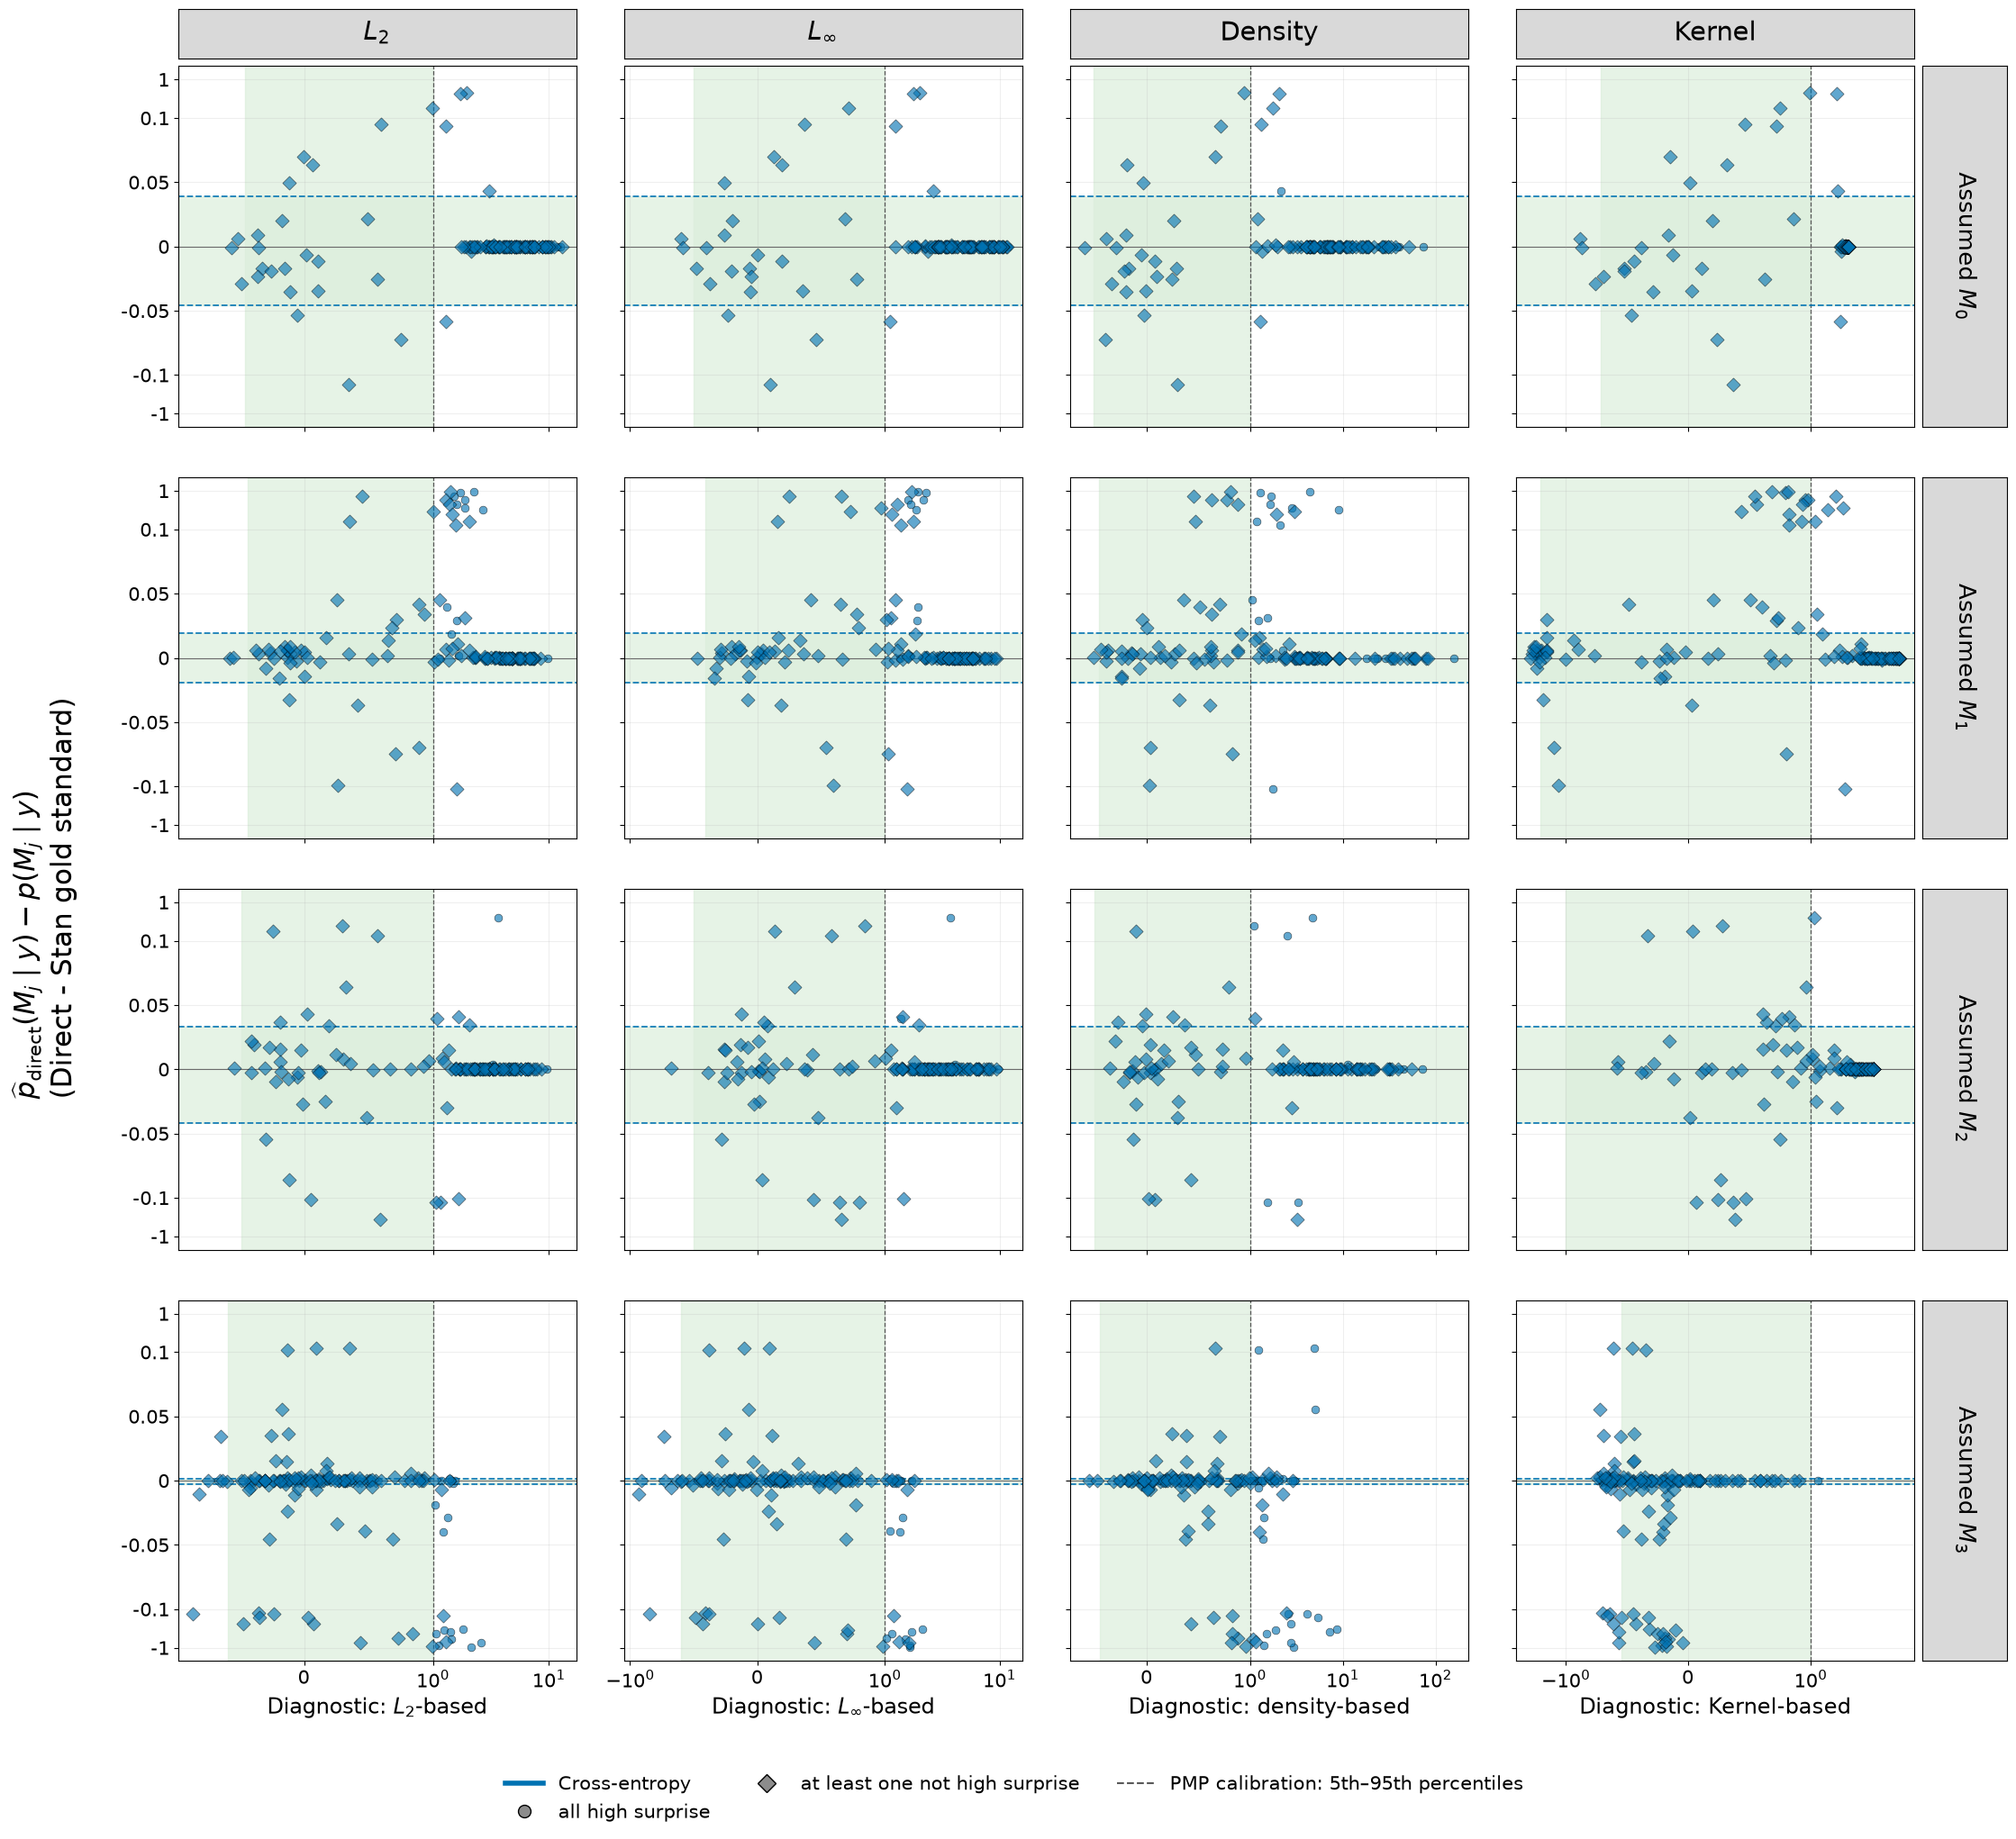

In [5]:
fig_diagnostic, axes_diagnostic = plt.subplots(
    4, 4, figsize=(23.5, 22), sharex="col", sharey=True,
)
fig_diagnostic.subplots_adjust(
    left=0.105, right=0.925, bottom=0.115, top=0.92, wspace=0.12, hspace=0.14,
)

for row, model in enumerate(MODELS):
    for col, diagnostic in enumerate(DIAGNOSTICS):
        ax = axes_diagnostic[row, col]
        panels = {
            loss: diagnostic_data_by_loss[loss].loc[(diagnostic, model)].loc[selected_index]
            for loss in LOSS_FUNCTIONS
        }
        threshold_rows = {loss: pmp_thresholds_by_loss[loss].loc[model] for loss in LOSS_FUNCTIONS}
        add_direct_background_regions(ax, panels, threshold_rows)
        ax.axhline(0, color="0.35", linewidth=0.8, zorder=1)

        for loss in LOSS_FUNCTIONS:
            panel = panels[loss]
            frame = plot_data_by_loss[loss]
            if not panel.index.equals(frame.index):
                raise ValueError(f"Plot alignment failed for {loss}/{diagnostic}/{model}")
            threshold_row = threshold_rows[loss]
            lower_error = float(threshold_row["lower_threshold"])
            upper_error = float(threshold_row["threshold"])
            for boundary in (lower_error, upper_error):
                ax.axhline(
                    boundary, color=LOSS_COLORS[loss], linestyle="--",
                    linewidth=1.3, alpha=0.9, zorder=2,
                )
            error = frame[f"p_direct_{model}"] - frame[f"p_gold_{model}"]
            for flag, (marker, size, label) in CLASS_STYLES.items():
                mask = panel["at_least_one_not_extrapolative"].eq(flag)
                ax.scatter(
                    panel.loc[mask, "rho"], error.loc[mask],
                    color=LOSS_COLORS[loss], marker=marker, s=size, alpha=0.62,
                    edgecolors="black", linewidths=0.45, zorder=3,
                )

        ax.set_xscale("symlog", linthresh=1)
        ax.set_yscale("symlog", linthresh=0.1, linscale=3)
        y_transform = ax.yaxis.get_transform()
        ax.set_ylim(y_transform.inverted().transform(y_transform.transform([-1, 1]) * 1.08))
        ax.set_yticks([-1, -0.1, -0.05, 0, 0.05, 0.1, 1],
                      labels=["-1", "-0.1", "-0.05", "0", "0.05", "0.1", "1"])
        ax.margins(x=0.04)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=15, labelbottom=row == 3, labelleft=col == 0)

for ax, xlabel in zip(axes_diagnostic[-1], DIAGNOSTIC_XLABELS):
    ax.set_xlabel(xlabel, fontsize=17)
    ax.set_xlim(left=min(0, ax.get_xlim()[0]))

# Gray facet strips match the reference notebook.
for ax, title in zip(axes_diagnostic[0], DIAGNOSTIC_TITLES):
    pos = ax.get_position()
    strip = fig_diagnostic.add_axes([pos.x0, pos.y1 + 0.004, pos.width, 0.025])
    strip.set(facecolor="0.85", xticks=[], yticks=[])
    strip.text(0.5, 0.5, title, ha="center", va="center", fontsize=21)

for ax, model in zip(axes_diagnostic[:, -1], MODELS):
    pos = ax.get_position()
    strip = fig_diagnostic.add_axes([pos.x1 + 0.004, pos.y0, 0.04, pos.height])
    strip.set(facecolor="0.85", xticks=[], yticks=[])
    strip.text(0.5, 0.5, rf"Assumed $M_{{{model[1:]}}}$",
               ha="center", va="center", rotation=-90, fontsize=19)

handles = [
    Line2D([], [], color=LOSS_COLORS[loss], lw=4, label=LOSS_LABELS[loss])
    for loss in LOSS_FUNCTIONS
] + [
    Line2D([], [], linestyle="none", marker=marker, markerfacecolor="0.55",
           markeredgecolor="black", markersize=10, label=label)
    for marker, size, label in CLASS_STYLES.values()
] + [
    Line2D([], [], color="0.35", linestyle="--", linewidth=1.5,
           label="PMP calibration: 5th–95th percentiles"),
]
fig_diagnostic.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.025),
                      ncol=3, frameon=False, fontsize=15, columnspacing=2.0)
fig_diagnostic.supylabel(
    r"$\widehat{p}_{\mathrm{direct}}(M_j\mid y)-p(M_j\mid y)$" + "\n(Direct - Stan gold standard)",
    x=0.025, fontsize=22,
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
diagnostic_figure_stem = FIGURE_DIR / f"direct_pmp_error_all_losses_by_diagnostic_{figure_suffix}"
for extension in ("png", "pdf"):
    fig_diagnostic.savefig(diagnostic_figure_stem.with_suffix(f".{extension}"),
                           dpi=200, bbox_inches="tight", pad_inches=0.12)
plt.show()
print(diagnostic_figure_stem)
